# Introducción
Este cuaderno de Jupyter está dedicado al análisis de imágenes satelitales para identificar y predecir áreas propensas a inundaciones. Utilizamos imágenes satelitales Sentinel y aplicamos técnicas de aprendizaje automático predictivo para mejorar la precisión. gestión de desastres.

## Configuración
En esta sección, instalamos e importamos todas las bibliotecas necesarias para nuestro análisis.

In [10]:
# Instalamos las librerias necesarias
!pip install sentinelhub numpy rasterio matplotlib scikit-learn pandas ipywidgets

pyenv: version `3.12' is not installed (set by /Users/gersongarrido/Projects/masters-degree-thesis/.python-version)
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.11.7
  3.13.3
  anaconda3-2024.10-1

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.


In [11]:
# Importamos las librerias necesarias
import numpy as np
from sentinelhub import SHConfig, BBox, CRS, SentinelHubRequest, DataCollection, MimeType, bbox_to_dimensions, Geometry, \
    MosaickingOrder, SentinelHubDownloadClient, SentinelHubCatalog
import matplotlib.pyplot as plt
from datetime import timedelta, datetime
from time import perf_counter, sleep
import os, shutil
from PIL import Image, ImageEnhance
import json
import pandas as pd
import rasterio

## Configuración de API
Para acceder a los datos satelitales desde Sentinel Hub, necesitamos configurar la API con nuestras credenciales. Es crucial mantener estas credenciales seguras y no exponerlas en repositorios públicos o entornos compartidos.

In [50]:
config = SHConfig()

config.sh_client_id = ""
config.sh_client_secret = ""

config.sh_token_url = 'https://services.sentinel-hub.com/auth/realms/main/protocol/openid-connect/token'
config.sh_base_url = 'https://services.sentinel-hub.com'
# config.save()
config.save()

## Área de estudio
Defina el área geográfica de interés mediante coordenadas. Esta área se utilizará para recuperar las imágenes de satélite.

In [51]:
# Coordenadas de el área de estudio
coordinates = [
    (-80.61366475225022, -5.303720591660726),
    (-80.60851994377389, -5.259328684726989),
    (-80.57403946583425, -5.191819220288488),
    (-80.68876497587912, -5.189889537506511),
    (-80.72116972996476, -5.189777131046656),
    (-80.73821275265747, -5.275669546184612),
    (-80.75641036272417, -5.300270025835458),
    (-80.61366475225022, -5.303720591660726)
]

# Calcular los límites de el área de estudio
min_lon = min(coord[0] for coord in coordinates)
max_lon = max(coord[0] for coord in coordinates)
min_lat = min(coord[1] for coord in coordinates)
max_lat = max(coord[1] for coord in coordinates)


# Crear un objeto BBox con los límites
bbox = BBox(bbox=[min_lon, min_lat, max_lon, max_lat], crs=CRS.WGS84)

# Resolución de la imagen
resolution = 10

# Calcular el tamaño de la imagen
aoi_size = bbox_to_dimensions(bbox, resolution=resolution)
print(aoi_size)

(2022, 1258)


In [52]:
MAX_CLOUD_COVERAGE = 25 # Este es el porcentaje máximo de cobertura de nubes permitido

In [53]:
catalog = SentinelHubCatalog(config=config)
# aoi_bbox = BBox(bbox=aoi_coords_wgs84, crs=CRS.WGS84)
time_interval = '2019-01-01', '2019-12-31'

search_iterator = catalog.search(
    DataCollection.SENTINEL2_L2A,
    bbox=bbox,
    time=time_interval,
    fields={"include": ["id", "properties.datetime"], "exclude": []},
)

results = list(search_iterator)
print("Total number of results:", len(results))

MAX_CLOUD_COVERAGE = 25 # Este es el porcentaje máximo de cobertura de nubes permitido

catalog_df = pd.DataFrame(results)
catalog_df.head()

Total number of results: 146


,id,properties
0,S2B_MSIL2A_20191231T155219_N0213_R111_T17MNQ_2...,{'datetime': '2019-12-31T15:54:31Z'}
1,S2B_MSIL2A_20191228T153619_N0213_R068_T17MNQ_2...,{'datetime': '2019-12-28T15:44:36Z'}
2,S2A_MSIL2A_20191226T155221_N0213_R111_T17MNQ_2...,{'datetime': '2019-12-26T15:54:31Z'}
3,S2A_MSIL2A_20191223T153611_N0213_R068_T17MNQ_2...,{'datetime': '2019-12-23T15:44:35Z'}
4,S2B_MSIL2A_20191221T155219_N0213_R111_T17MNQ_2...,{'datetime': '2019-12-21T15:54:31Z'}


## Adquisición de imágenes satelitales

Vamos a obtener imágenes satelitales para nuestro área de estudio. Este proceso implica especificar el rango de tiempo para las imágenes y seleccionar la colección de datos adecuada (por ejemplo, Sentinel-2 L2A para una corrección atmosférica de mayor calidad).

In [47]:
# Definimos el script de evaluación para obtener la imagen en color verdadero
evalscript_true_color = """
    //VERSION=3

    function setup() {
        return {
            input: [{ bands: ["B02", "B03", "B04"] }],
            output: { bands: 3 }
        };
    }

    function evaluatePixel(sample) {
      return [2.5 * sample.B04, 2.5 * sample.B03, 2.5 * sample.B02];
    }
"""

In [48]:
def plot_image(image, factor=1/255, clip_range=(0, 1), **kwargs):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 15))
    if clip_range is not None:
        ax.imshow(np.clip(image * factor, *clip_range), **kwargs)
    else:
        ax.imshow(image * factor, **kwargs)
    ax.set_xticks([])
    ax.set_yticks([])


def get_satellite_image(evalscript, time_interval, save_data, data_folder='./data/images', return_data=False):
    sentinel_request = SentinelHubRequest(
        data_folder=data_folder,
        evalscript=evalscript,
        input_data=[SentinelHubRequest.input_data(
            time_interval=time_interval,
            data_collection=DataCollection.SENTINEL2_L2A.define_from(
                name="s2", service_url="https://sh.dataspace.copernicus.eu"
            ),
            mosaicking_order=MosaickingOrder.LEAST_CC,
            other_args={'dataFilter': {'maxCloudCoverage': MAX_CLOUD_COVERAGE}}
        )],
        bbox=bbox,
        config=config,
        size=aoi_size,
        responses=[SentinelHubRequest.output_response('default', MimeType.TIFF)]
    )
    if return_data:
        return sentinel_request.get_data(save_data=save_data)

    response = sentinel_request.get_data(save_data=save_data)[0]
    return response

In [49]:
image = get_satellite_image(evalscript_true_color, ('2018-01-22', '2018-01-28'), save_data=True)
plot_image(image)

InvalidClientError: (invalid_client) Invalid client or Invalid client credentials

## Procesamiento de imágenes satelitales y cálculo del NDVI
Para calcular el Índice de Vegetación de Diferencia Normalizada (NDVI), necesitamos las bandas roja (B04) y cercana al infrarrojo (B08) de las imágenes satelitales. Vamos a solicitar estas bandas para nuestro análisis.

In [ ]:
# Definiendo el script de evaluación para obtener el NDVI
evalscript_ndvi_values = """

//VERSION=3
    function setup() {
      return{
        input: [{
          bands: ["B04", "B08"]
        }],
        output: {
          bands: 1,
        }
      }
    }



    function evaluatePixel(sample) {
      let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04)
      return [ ndvi ]
    }
"""

In [ ]:
ndvi_image = get_satellite_image(evalscript_ndvi_values, ('2018-01-01', '2018-01-07'), save_data=False)

# Visualizar el resultado del NDVI de la primera imagen
plt.figure(figsize=(10, 10))
plt.imshow(ndvi_image, cmap='RdYlGn')
plt.colorbar()
plt.title('NDVI Image')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.show()

La imagen mostrada representa el Índice de Vegetación de Diferencia Normalizada (NDVI), una herramienta ampliamente utilizada para evaluar la presencia y condición de la vegetación. La escala de colores de la derecha, que va de -1 a 1, ayuda a interpretar la imagen:
* Tonos rojo y marrón (-1 a 0): estos colores generalmente indican valores de NDVI más bajos, lo que sugiere áreas con escasa o nula vegetación, como entornos urbanos, cuerpos de agua, tierras áridas o regiones con escasa vegetación.
* Tonos de amarillo a verde claro (0 a 0,5): estos tonos representan valores moderados de NDVI, que a menudo señalan áreas con arbustos, pastizales o paisajes parcialmente vegetados.
* Tonos de verde oscuro (0,5 a 1): Los tonos de verde oscuro significan valores altos de NDVI, indicativos de una vegetación densa y saludable, como bosques o campos agrícolas en buen estado.

En esta imagen en particular:

* Es probable que las áreas que se muestran en verde oscuro sean vegetación densa o campos agrícolas.
* Las áreas de color amarillo a verde claro pueden ser indicativas de vegetación menos densa o zonas de vegetación de transición.
* Las áreas rojas y marrones podrían representar regiones urbanas, suelo desnudo o cuerpos de agua, que reflejan una presencia mínima o nula de vegetación.

Esta visualización del NDVI ayuda a evaluar rápidamente la salud y la distribución de la vegetación en diferentes regiones, lo cual es fundamental para las tareas de monitoreo y gestión ambiental, como la evaluación del riesgo de inundaciones en paisajes tanto agrícolas como naturales.

## Calculo del NDWI

Para detectar la presencia de agua utilizando imágenes satelitales, se pueden emplear diferentes técnicas y bandas espectrales que son especialmente sensibles al agua. A continuación, se explica cómo utilizar el Índice de Agua Normalizado (NDWI) y otras técnicas basadas en el análisis espectral:

### Índice de Agua Normalizado (NDWI)

El NDWI es una herramienta efectiva para identificar y monitorear cuerpos de agua, especialmente útil en la detección de cambios en la extensión de ríos, lagos y humedales. El NDWI se calcula usando las siguientes bandas espectrales:

* Banda del verde (B03): Captura la reflectancia en la región verde del espectro.
* Banda del infrarrojo cercano (B08): Sensible a la vegetación y la humedad.

La fórmula del NDWI es:
 $$
 {NDWI} = \frac{(B03 - B08)}{(B03 + B08)}
 $$

Donde:

* ( B03 ) es la reflectancia en la banda verde.
* B08  es la reflectancia en la banda del infrarrojo cercano.

Los valores de NDWI cercanos a +1 indican la presencia de agua, mientras que valores cercanos a -1 suelen indicar la ausencia de agua.


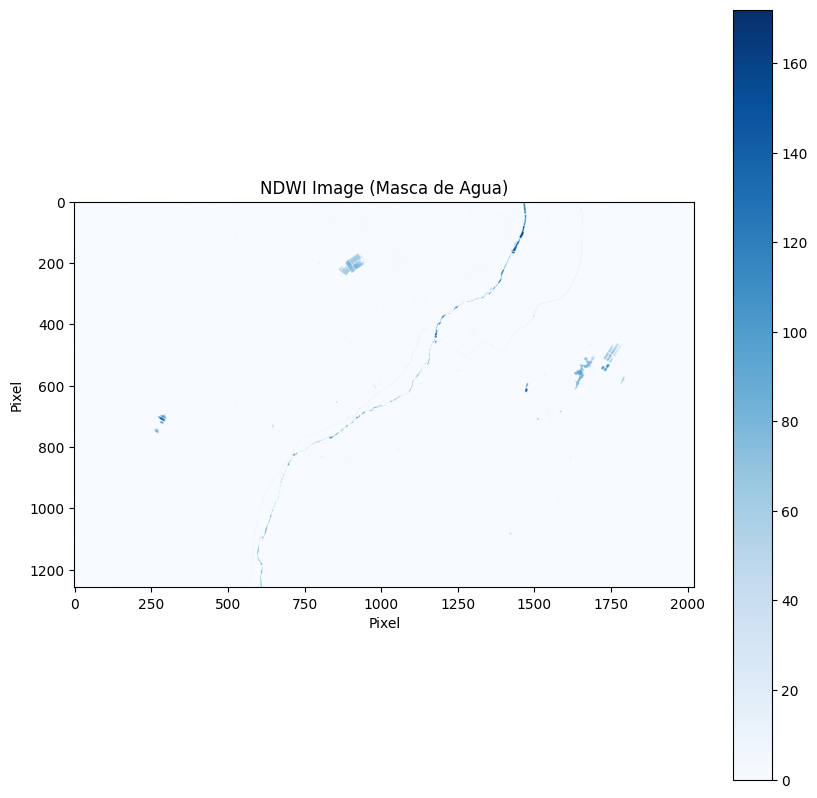

In [26]:
evalscript_ndwi_values = """
//VERSION=3
    function setup() {
      return{
        input: [{
          bands: ["B03", "B08"]
        }],
        output: {
          bands: 1,
        }
      }
    }



    function evaluatePixel(sample) {
      let ndwi = (sample.B03 - sample.B08) / (sample.B03 + sample.B08)
      return [ ndwi ]
    }
"""

ndwi_image = get_satellite_image(evalscript_ndwi_values, ('2021-01-01', '2021-12-31'), save_data=False)

# Visualizar el resultado del NDWI de la primera imagen
plt.figure(figsize=(10, 10))
plt.imshow(ndwi_image, cmap='Blues')
plt.colorbar()
plt.title('NDWI Image (Masca de Agua)')
plt.xlabel('Pixel')
plt.ylabel('Pixel')
plt.show()

De la imagen NDWI, podemos inferir la presencia de agua en diferentes áreas de la región. Los tonos azules más oscuros indican la presencia de agua, mientras que los tonos más claros representan otros tipos de cobertura terrestre. Esta información es valiosa para identificar cuerpos de agua, humedales y áreas propensas a inundaciones, lo que puede ser crucial para la gestión de desastres y la planificación del uso de la tierra.